In [1]:
import json
import os
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

# ==========================================
# 1. PATHS & DATASET CLASS
# ==========================================
BASE_KAGGLE_DIR = "/kaggle/input/datasets/hrushi1998/vr-mini-proj-dataset/Trimmed_Dataset" 
TRAIN_DIR = f"{BASE_KAGGLE_DIR}/trimmed_train_data"
VAL_DIR = f"{BASE_KAGGLE_DIR}/trimmed_val_data"
TRAIN_JSON_PATH = f"{TRAIN_DIR}/processed_train_data.json"
VAL_JSON_PATH = f"{VAL_DIR}/processed_val_data.json"

class KaggleClothingDataset(Dataset):
    def __init__(self, json_file, img_dir, transform=None):
        with open(json_file, 'r') as f:
            full_data = json.load(f)
            
        self.data = full_data["data"]
        self.top_5_categories = full_data.get("top_5_categories", [1, 8, 7, 2, 9])
        self.transform = transform
        self.img_dir = img_dir
        self.label_map = {cat_id: idx for idx, cat_id in enumerate(self.top_5_categories)}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        full_image_path = os.path.join(self.img_dir, item["image_path"])
        
        try:
            image = Image.open(full_image_path).convert('RGB')
        except Exception:
            return torch.zeros((3, 224, 224)), torch.zeros(5)

        if self.transform:
            image = self.transform(image)

        target = torch.zeros(5, dtype=torch.float32)
        for cat_id in item["classification_labels"]:
            if cat_id in self.label_map:
                target[self.label_map[cat_id]] = 1.0

        return image, target

# ==========================================
# 2. TRANSFORMS & SPLITTING
# ==========================================
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)), 
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Loading datasets into memory...")
train_dataset = KaggleClothingDataset(TRAIN_JSON_PATH, TRAIN_DIR, transform=train_transforms)
full_val_dataset = KaggleClothingDataset(VAL_JSON_PATH, VAL_DIR, transform=eval_transforms)

val_size = len(full_val_dataset) // 2
test_size = len(full_val_dataset) - val_size

val_dataset, test_dataset = random_split(
    full_val_dataset, 
    [val_size, test_size], 
    generator=torch.Generator().manual_seed(42) 
)

BATCH_SIZE = 128  
NUM_WORKERS = 4  

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"✅ Dataset Splitting Complete! Batches of {BATCH_SIZE} ready.")

Loading datasets into memory...
✅ Dataset Splitting Complete! Batches of 128 ready.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision.models import ResNet50_Weights
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. BUILD RESNET-50 (Custom Freeze Strategy)
# ==========================================
print("Downloading Pretrained ResNet-50...")
model_resnet = models.resnet50(weights=ResNet50_Weights.DEFAULT)

# Freeze the early layers (speeds up training & stabilizes weights)
for param in model_resnet.parameters():
    param.requires_grad = False

# Unfreeze layer4 and replace the final classification head
for param in model_resnet.layer4.parameters():
    param.requires_grad = True

num_features = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_features, 5) 

# 🔥 THE DUAL-GPU MAGIC LINE
if torch.cuda.device_count() > 1:
    print(f"🔥 Turbo Mode Activated: Splitting work across {torch.cuda.device_count()} GPUs!")
    model_resnet = nn.DataParallel(model_resnet)

model_resnet = model_resnet.to(device)

# ==========================================
# 2. LOSS & OPTIMIZER (Multi-Label)
# ==========================================
criterion = nn.BCEWithLogitsLoss() 
optimizer = optim.Adam(model_resnet.parameters(), lr=0.001)

# ==========================================
# 3. HIGH-SPEED TRAINING LOOP
# ==========================================
best_val_loss = float('inf')  # <-- ADDED: Initialize the best score tracker
num_epochs = 20               # <-- BUMPED TO 20 (Now safe to do!)

for epoch in range(num_epochs):
    print(f"\n--- Epoch {epoch+1}/{num_epochs} ---")
    model_resnet.train()
    running_loss = 0.0
    
    train_bar = tqdm(train_loader, desc="Training")
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_resnet(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")
        
    avg_train_loss = running_loss / len(train_loader)
    
    # --- Quick Validation Pass ---
    model_resnet.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_resnet(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    print(f"Train Loss: {avg_train_loss:.4f} | Validation Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        print(f" New best validation score! Auto-saving weights...")
        
        if isinstance(model_resnet, nn.DataParallel):
            torch.save(model_resnet.module.state_dict(), "resnet50_clothing_model_best.pth")
        else:
            torch.save(model_resnet.state_dict(), "resnet50_clothing_model_best.pth")

print("\n ResNet-50 successfully trained on dual GPUs!")

print("\nSaving final epoch weights as a backup...")

# Keeps your original save at the bottom as a backup of the absolute last epoch
if isinstance(model_resnet, nn.DataParallel):
    torch.save(model_resnet.module.state_dict(), "resnet50_clothing_model_last.pth")
else:
    torch.save(model_resnet.state_dict(), "resnet50_clothing_model_last.pth")

print("Training sequence completely finished!")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 190MB/s]


🔥 Turbo Mode Activated: Splitting work across 2 GPUs!

--- Epoch 1/20 ---


Training: 100%|██████████| 1127/1127 [12:48<00:00,  1.47it/s, loss=0.2944]


Train Loss: 0.2740 | Validation Loss: 0.2432
 New best validation score! Auto-saving weights...

--- Epoch 2/20 ---


...

Train Loss: 0.0493 | Validation Loss: 0.3546

--- Epoch 19/20 ---


Training: 100%|██████████| 1127/1127 [09:17<00:00,  2.02it/s, loss=0.1158]


Train Loss: 0.0472 | Validation Loss: 0.3575

--- Epoch 20/20 ---


Training: 100%|██████████| 1127/1127 [09:19<00:00,  2.01it/s, loss=0.0331]


Train Loss: 0.0443 | Validation Loss: 0.3553

 ResNet-50 successfully trained on dual GPUs!

Saving final epoch weights as a backup...
Training sequence completely finished!


Evaluating ResNet-50 on the Test Set (Sigmoid Threshold = 0.5)...


Testing: 100%|██████████| 93/93 [01:00<00:00,  1.53it/s]



🚀 PROJECT METRICS (Classification)
Micro Precision: 0.8661
Micro Recall:    0.8307
Micro F1-Score:  0.8480
Macro F1-Score:  0.8341

Per-Category Breakdown:
                  precision    recall  f1-score   support

Short Sleeve Top       0.90      0.84      0.87      6298
        Trousers       0.90      0.88      0.89      4771
          Shorts       0.78      0.79      0.78      2048
 Long Sleeve Top       0.81      0.76      0.78      2907
           Skirt       0.87      0.83      0.85      3223

       micro avg       0.87      0.83      0.85     19247
       macro avg       0.85      0.82      0.83     19247
    weighted avg       0.87      0.83      0.85     19247
     samples avg       0.86      0.84      0.83     19247



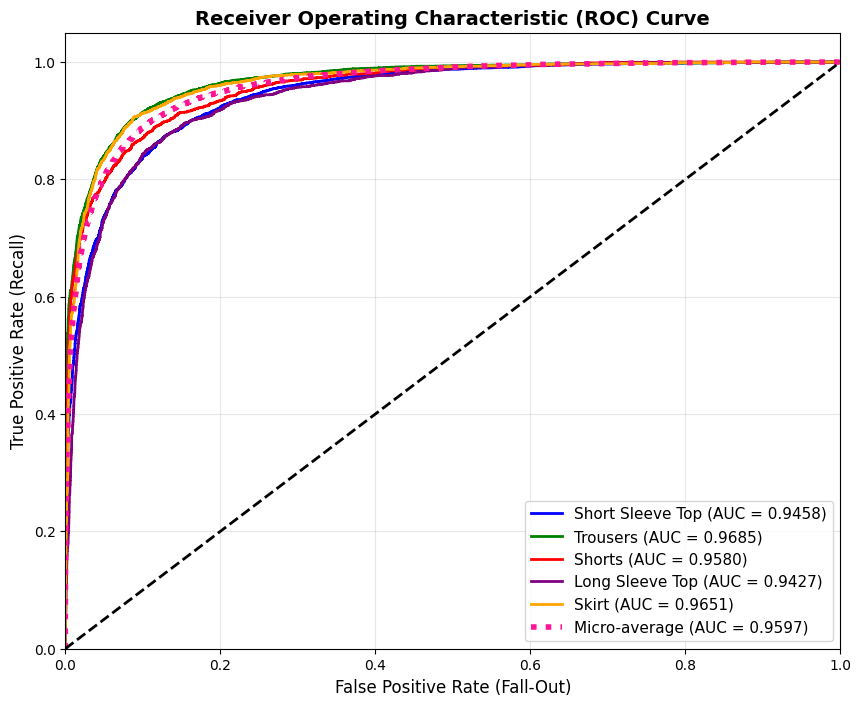

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, roc_curve, auc, accuracy_score
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')

# ==========================================
# 4. METRICS & ROC EVALUATION SCRIPT
# ==========================================
print("Evaluating ResNet-50 on the Test Set (Sigmoid Threshold = 0.5)...")

model_resnet.eval()

all_preds = []
all_labels = []
all_probs = [] 

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        
        outputs = model_resnet(images)
        
        # Sigmoid converts raw logits to percentages
        probs = torch.sigmoid(outputs)
        # Apply the 0.5 threshold to get the hard 1s and 0s
        preds = (probs > 0.5).float()
        
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.vstack(all_probs)
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

# --- CALCULATE METRICS ---
micro_f1 = f1_score(all_labels, all_preds, average='micro', zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
micro_prec = precision_score(all_labels, all_preds, average='micro', zero_division=0)
micro_recall = recall_score(all_labels, all_preds, average='micro', zero_division=0)


final_accuracy = accuracy_score(all_labels, all_preds)

print("\n" + "="*45)
print("🚀 PROJECT METRICS (Classification)")
print("="*45)
print(f"Micro Precision: {micro_prec:.4f}")
print(f"Micro Recall:    {micro_recall:.4f}")
print(f"Micro F1-Score:  {micro_f1:.4f}")
print(f"Macro F1-Score:  {macro_f1:.4f}")
print("="*45)

categories = ["Short Sleeve Top", "Trousers", "Shorts", "Long Sleeve Top", "Skirt"] 
print("\nPer-Category Breakdown:")
print(classification_report(all_labels, all_preds, target_names=categories, zero_division=0))

# --- PLOT ROC CURVE ---
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'purple', 'orange']

# Calculate and plot ROC for each individual class
for i in range(5):
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{categories[i]} (AUC = {roc_auc:.4f})')

# Calculate and plot the Micro-average ROC
fpr_micro, tpr_micro, _ = roc_curve(all_labels.ravel(), all_probs.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, color='deeppink', linestyle=':', lw=4, 
         label=f'Micro-average (AUC = {roc_auc_micro:.4f})')

# Graph Formatting
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Fall-Out)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.savefig("/kaggle/working/resnet50_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()